In [44]:
from pathlib import Path
import scanpy as sc

file_path = Path.home() / "projects" / "multiome-integration-scRNA-scATAC" / "data" / "processed" / "rna_qc_filtered.h5ad"

rna_filt = sc.read_h5ad(file_path)

In [45]:
rna_filt

AnnData object with n_obs × n_vars = 9438 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt'

In [46]:
rna_filt.layers["counts"] = rna_filt.X.copy()

In [47]:
sc.pp.normalize_total(rna_filt, target_sum=1e4) #compare between cells
sc.pp.log1p(rna_filt)

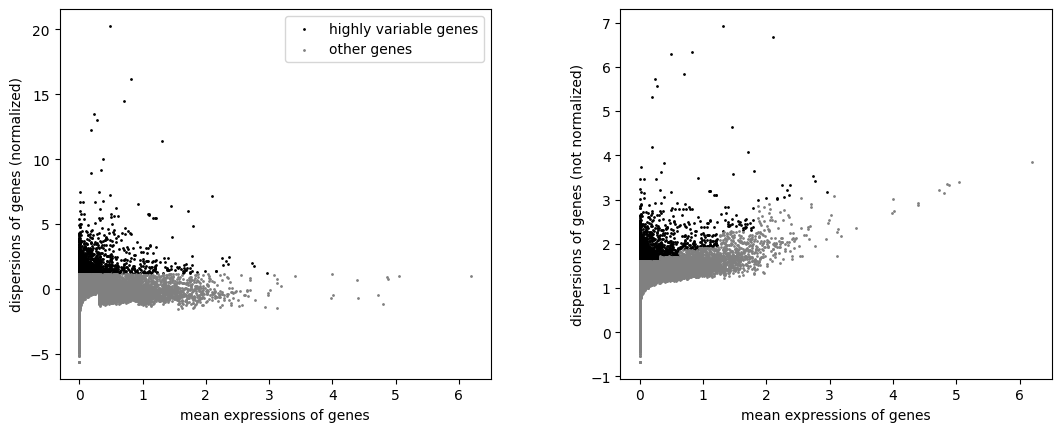

In [48]:
sc.pp.highly_variable_genes(rna_filt, n_top_genes=2000)
sc.pl.highly_variable_genes(rna_filt)

In [49]:
rna_filt = rna_filt[:, rna_filt.var.highly_variable].copy()
print(rna_filt)

AnnData object with n_obs × n_vars = 9438 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'


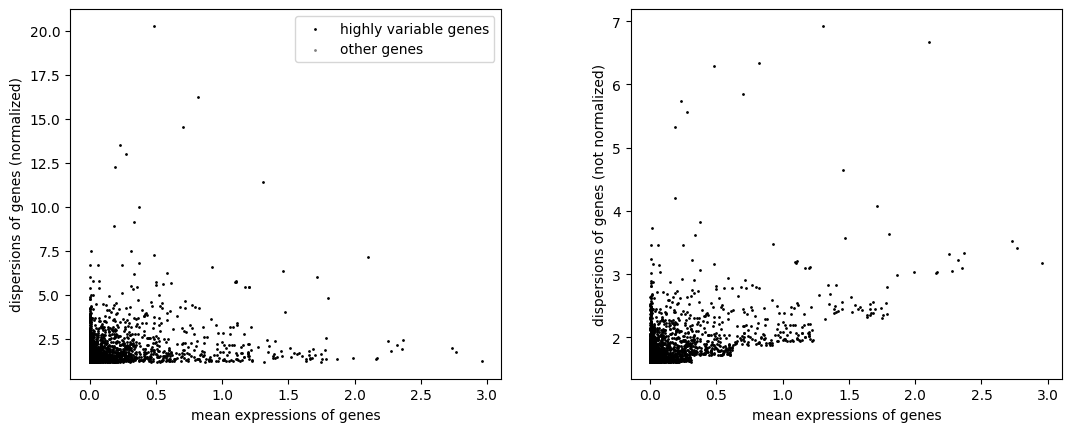

In [50]:
sc.pl.highly_variable_genes(rna_filt)

In [51]:
sc.pp.scale(rna_filt) #standardization (compare between genes)
sc.tl.pca(rna_filt)

/Users/dayejung/conda/envs/multiome-RNA-ATAC/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


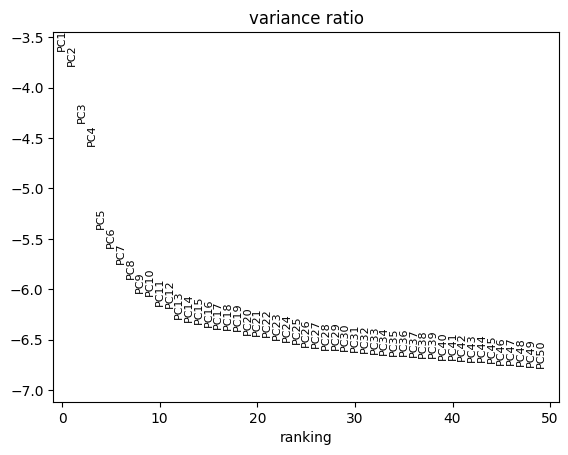

In [52]:
sc.pl.pca_variance_ratio(rna_filt, n_pcs=50, log=True)

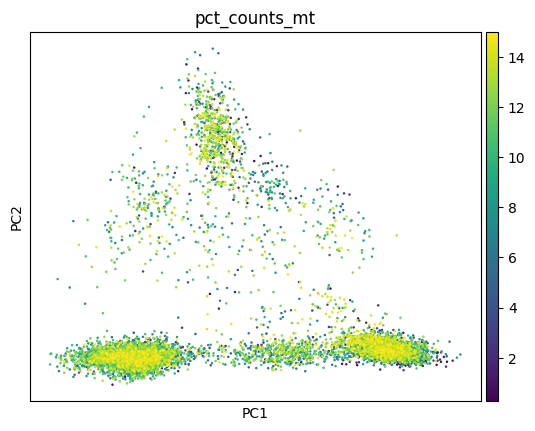

In [53]:
sc.pl.pca(
    rna_filt,
    color=["pct_counts_mt"],
)

In [54]:
sc.pp.neighbors(rna_filt)

In [55]:
sc.tl.umap(rna_filt)

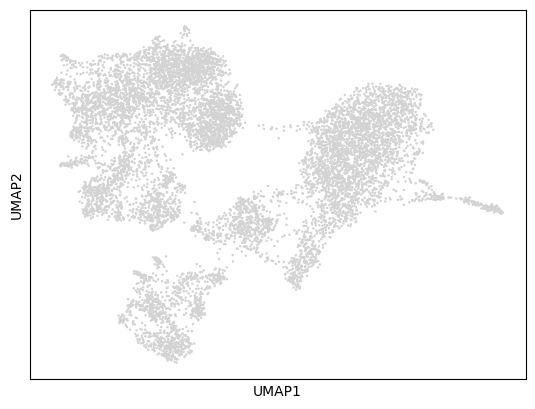

In [56]:
sc.pl.umap(rna_filt)

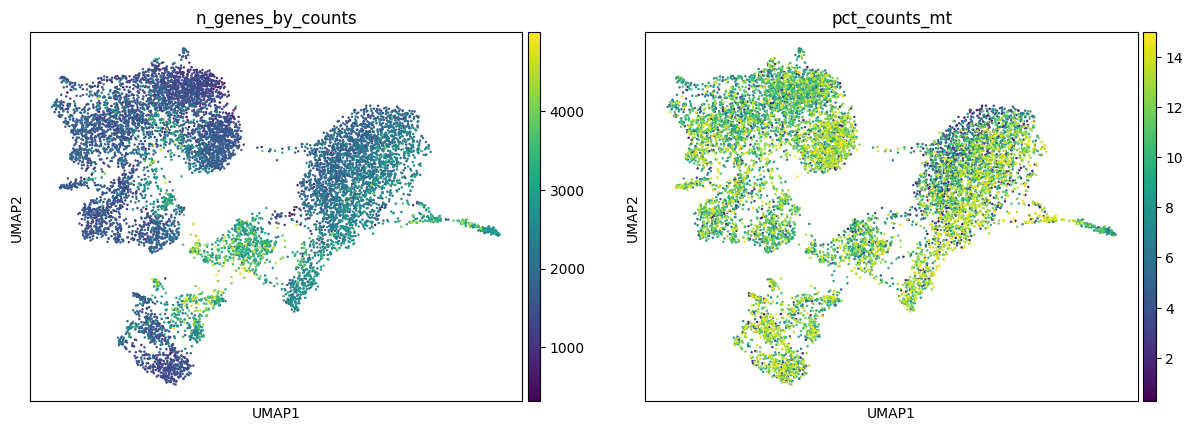

In [57]:
sc.pl.umap(rna_filt, color=["n_genes_by_counts", "pct_counts_mt"])